In [41]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt

%matplotlib inline

# Task 0
Data extraction: get the data from 3 tables & combine it into single `.csv` file.
After that read this file using pandas to create Dataframe.
So it will be all joined data in 1 dataframe. Quick check - should be 74818 rows in it.

In [50]:
conn = sqlite3.connect("../db.sqlite3")
query = """
SELECT
restaurant_order.id as order_id,
restaurant_order.datetime,
restaurant_product.id as product_id,
restaurant_product.name,
restaurant_orderitem.quantity,
restaurant_product.price,
restaurant_orderitem.quantity * price as line_total
FROM restaurant_orderitem
JOIN restaurant_order ON restaurant_order.id = restaurant_orderitem.order_id
JOIN restaurant_product ON restaurant_product.id = restaurant_orderitem.product_id
ORDER BY restaurant_orderitem.order_id
"""
data = pd.read_sql_query(query, conn)

data.to_csv("product_sales.csv", index=False)

df = pd.read_csv("product_sales.csv")
df.head()

,order_id,datetime,product_id,name,quantity,price,line_total
0,1,2019-08-03 20:25:00,6,Plain Papadum,2,0.80,1.60
1,1,2019-08-03 20:25:00,240,King Prawn Balti,1,12.95,12.95
2,1,2019-08-03 20:25:00,19,Garlic Naan,1,2.95,2.95
3,1,2019-08-03 20:25:00,36,Mushroom Rice,1,3.95,3.95
4,1,2019-08-03 20:25:00,111,Paneer Tikka Masala,1,8.95,8.95


# Task 1
Get Top 10 most popular products in restaurant sold by Quantity.
Count how many times each product was sold and create a pie chart with percentage of popularity (by quantity) for top 10 of them.

Example:

![pie chart](../demo/pie.png)

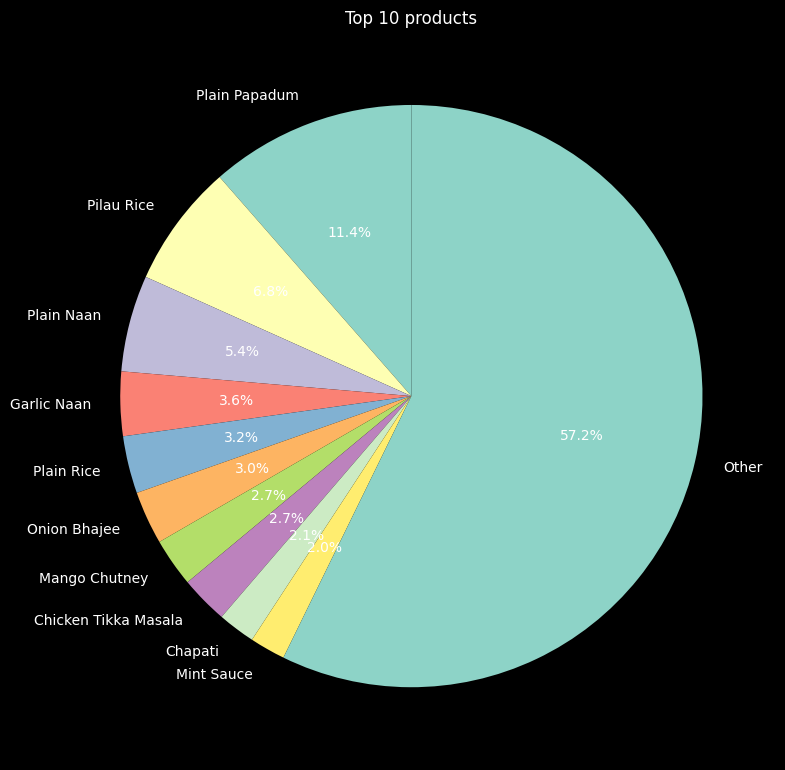

In [51]:
product_quantity = df.groupby("name")["quantity"].sum()
product_percentage = (product_quantity / product_quantity.sum()) * 100
top_10 = product_percentage.sort_values(ascending=False)[:10]
other = product_percentage.sort_values(ascending=False)[10:].sum()
data = pd.concat([top_10, pd.Series({"Other": other})])
plt.figure(figsize=(8, 8))
plt.pie(data, labels=data.index, autopct='%1.1f%%', startangle=90)
plt.title("Top 10 products")
plt.tight_layout()
plt.show()

# Task 2
Calculate `Item Price` (Product Price * Quantity) for each Order Item in dataframe.
And Make the same Top 10 pie chart, but this time by `Item Price`. So this chart should describe not the most popular products by quantity, but which products (top 10) make the most money for restaurant. It should be also with percentage.

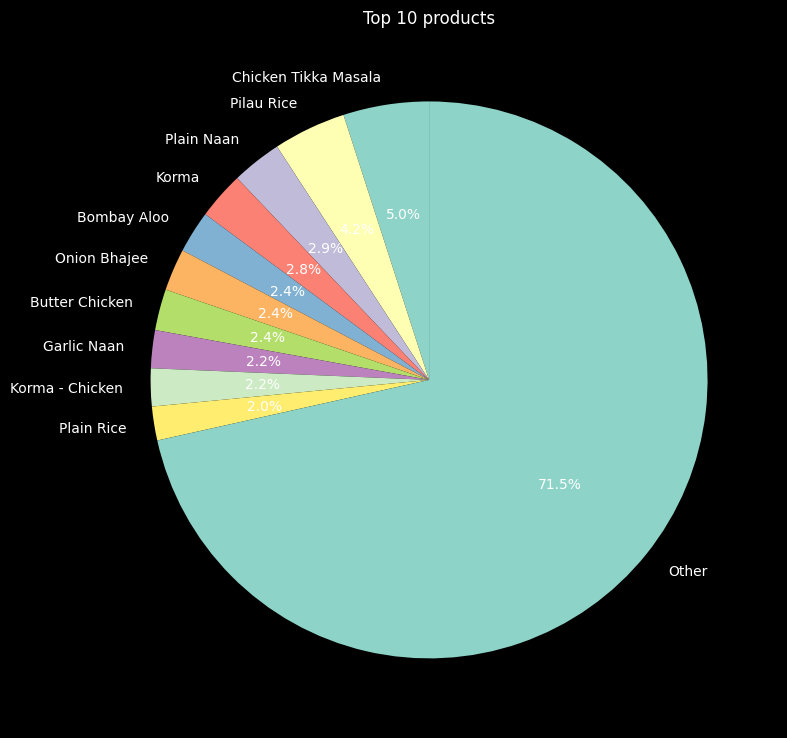

In [52]:
product_sales = df.groupby("name")["line_total"].sum()
product_percentage = (product_sales / product_sales.sum()) * 100
top_10 = product_percentage.sort_values(ascending=False)[:10]
other = product_percentage.sort_values(ascending=False)[10:].sum()
data = pd.concat([top_10, pd.Series({"Other": other})])
plt.figure(figsize=(8, 8))
plt.pie(data, labels=data.index, autopct='%1.1f%%', startangle=90)
plt.title("Top 10 products")
plt.tight_layout()
plt.show()

# Task 3
Calculate `Order Hour` based on `Order Datetime`, which will tell about the specific our the order was created (from 0 to 23). Using `Order Hour` create a bar chart, which will tell the total restaurant income based on the hour order was created. So on x-axis - it will be values from 0 to 23 (hours), on y-axis - it will be the total sum of order prices, which were sold on that hour.

Example:

![bar chart](../demo/bar.png)

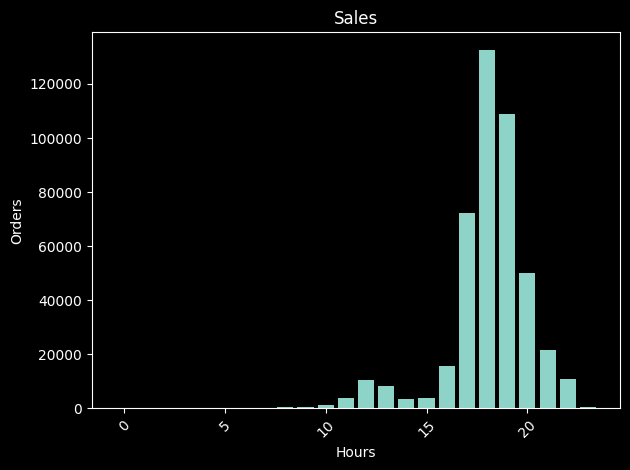

In [53]:
df["datetime"] = pd.to_datetime(df["datetime"])
df["order_hour"] = df["datetime"].dt.hour
unique_hours = (
    df.groupby("order_hour")["line_total"]
    .sum()
    .reset_index(name="sales")
)
plt.bar(unique_hours["order_hour"], unique_hours["sales"])
plt.title("Sales")
plt.xlabel("Hours")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Task 4
Make similar bar chart, but right now with `Order Day Of The Week` (from Monday to Sunday), and also analyze total restaurant income by each day of the week.

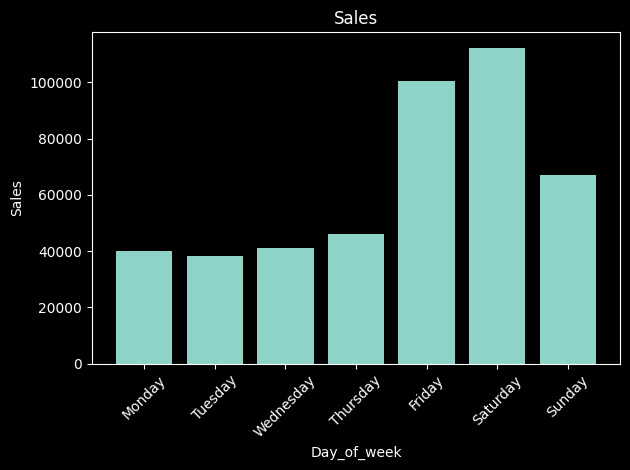

In [54]:
df["datetime"] = pd.to_datetime(df["datetime"])
df["day_of_week"] = df["datetime"].dt.day_name()
week_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
days_of_week = (
    df.groupby("day_of_week")["line_total"]
    .sum()
    .reindex(week_order)
    .reset_index(name="sales")
)
plt.bar(days_of_week["day_of_week"], days_of_week["sales"])
plt.title("Sales")
plt.xlabel("Day_of_week")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()